In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df =  pd.read_csv('student_performance_linear.csv')
# print(df.head())
# print(df.sample(10))

# pd.set_option('display.max_rows', None)
# print(df.sample(frac=0.10))

print(df.tail())
print(type(df))

     study_hours  exam_score
634          5.7          84
635          0.3          37
636          8.7         100
637          3.4          67
638          7.9          99
<class 'pandas.core.frame.DataFrame'>


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  639 non-null    float64
 1   exam_score   639 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 10.1 KB


In [4]:
print(df.columns)

Index(['study_hours', 'exam_score'], dtype='object')


In [9]:
x = df['study_hours'].values
y = df['exam_score'].values
print(type(y))

<class 'numpy.ndarray'>


In [8]:
# x = df.iloc[:,0:1]
# y = df.iloc[:,-1]
# print(type(y))

<class 'pandas.core.series.Series'>


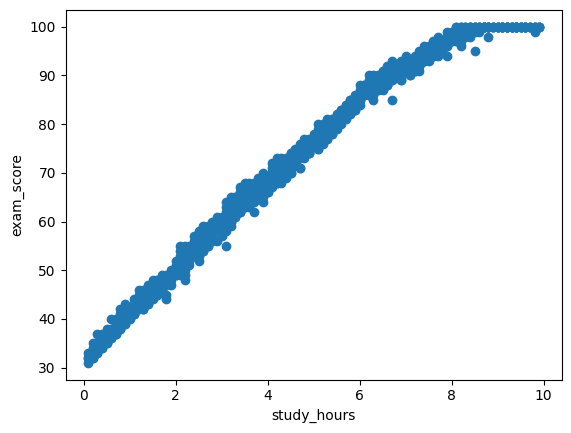

In [7]:
# df.plot.scatter(x="study_hours",y="exam_score")
plt.scatter(df['study_hours'],df['exam_score'])
plt.xlabel('study_hours')
plt.ylabel('exam_score')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 2)

In [11]:
threshold = 5
lr = 0.01
m,c = 0,0
for epoch in range(1000):
    y_pred = m*x_train+c
    cost = np.mean((y_pred-y_train)**2)
    # print(cost)
    if (cost<threshold):
        break
    dJ_dm = np.mean((2*x_train)*(y_pred-y_train))
    dJ_dc =np.mean((2)*(y_pred-y_train))
    m = m - lr*(dJ_dm)
    c = c - lr*(dJ_dc)
y_pred =m*x_train+c
cost = np.mean((y_pred-y_train)**2)
print({m,c})
# print(type(x),type(y))
print(cost)

{np.float64(35.931455280737744), np.float64(7.613135446568727)}
12.101736063803969


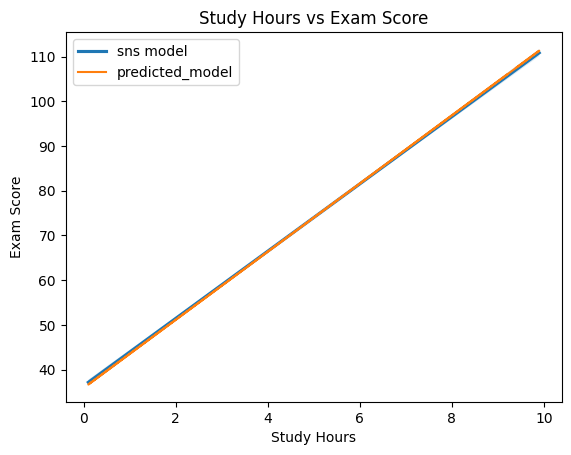

In [15]:
#using sns- interally it used OLS(ordinary least square method)
sns.regplot(
    x="study_hours",
    y="exam_score",
    data=df,
    scatter =False,
    label="sns model"
)
plt.plot(x_train, y_pred,label="predicted_model")
# Add standard labels
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.legend()
plt.show()

In [33]:
##find m,c from sns regression plot:Using Numpy
m,c = np.polyfit(df['study_hours'],df['exam_score'],1)
print("slope (m):",m)
print("intercept (c):",c)

slope (m): 7.514606781564881
intercept (c): 36.439114990615984


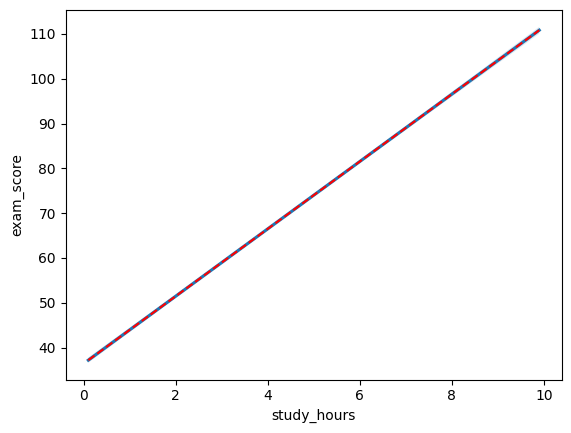

In [39]:
m, c = np.polyfit(df["study_hours"],
                  df["exam_score"], 1)

sns.regplot(
    x="study_hours",
    y="exam_score",
    data=df,
    scatter=False
)

x = np.linspace(df["study_hours"].min(),
                df["study_hours"].max(), 100)

plt.plot(x, m*x + c, 'r--')
plt.show()

In [17]:
##find m,c from sns regression plot:Using scikit-learn
from sklearn.linear_model import LinearRegression
# X=df[["study_hours"]]  #for x scikit expect 2D structure
# Y=df["exam_score"] #for y scikit expect 1D structure
model = LinearRegression()
model.fit(x_train,y_train)
m = model.coef_[0]
c = model.intercept_
print("Slope:", m)
print("Intercept:", c)
print(type(X))
print(type(Y))
# print(np.mean(Y-m*x-c))

ValueError: Expected 2D array, got 1D array instead:
array=[9.2 1.9 9.3 3.1 1.  0.2 7.1 3.5 3.2 1.5 0.7 1.5 8.2 9.1 6.3 6.5 8.4 0.6
 6.4 5.8 4.1 2.8 0.7 8.3 0.2 6.3 9.2 5.5 5.2 7.6 3.4 6.8 8.6 9.2 5.9 4.4
 3.6 8.5 6.7 4.1 9.4 4.9 0.9 7.6 8.8 5.4 5.6 2.1 9.7 5.6 7.1 7.3 5.8 4.6
 4.  6.3 7.4 4.4 4.5 7.4 8.1 0.3 7.4 1.3 2.3 9.7 0.8 9.3 3.3 7.7 7.7 5.9
 8.  8.1 5.2 5.1 0.5 8.1 8.2 8.8 2.6 0.4 6.8 0.3 3.7 3.2 1.9 1.4 7.3 1.4
 6.2 8.2 8.6 4.8 4.1 4.3 1.1 3.8 0.4 1.7 7.9 2.  0.6 4.4 1.4 0.4 4.  9.
 5.7 8.6 5.4 3.  7.2 3.4 7.5 4.3 6.8 0.3 1.8 9.1 0.2 1.6 3.8 0.9 0.3 9.1
 8.4 9.6 0.8 0.5 9.  0.6 6.3 5.9 7.4 5.4 1.4 2.6 5.  5.7 3.3 2.  8.9 9.4
 1.3 4.3 6.1 9.6 3.2 5.5 3.2 4.9 9.4 7.7 1.2 8.8 3.1 1.1 3.4 4.3 1.  3.8
 8.2 3.4 8.3 0.4 2.1 4.  2.2 7.  5.7 8.8 3.4 6.9 3.3 2.6 3.4 4.4 3.2 6.4
 9.1 8.1 4.  6.9 8.3 0.5 0.6 2.8 7.7 6.6 0.3 5.6 4.5 7.3 2.8 6.  5.4 7.5
 9.6 9.7 3.9 0.7 6.9 6.1 5.4 9.  1.3 8.8 4.2 6.  9.4 8.7 5.3 5.  1.1 9.4
 7.9 4.5 9.5 7.1 8.5 6.7 9.3 7.7 6.  7.2 7.  5.3 4.4 9.2 0.5 2.4 2

In [40]:
# #Later Understand: sns using OLS

# import numpy as np
# import pandas as pd
# import statsmodels.api as sm
# import matplotlib.pyplot as plt

# # Data
# x = df["study_hours"]
# y = df["exam_score"]

# # Add intercept column
# X = sm.add_constant(x)

# # Fit OLS model
# model = sm.OLS(y, X)

# # Train model
# results = model.fit()

# # Get coefficients
# c = results.params["const"]
# m = results.params["study_hours"]

# print("Intercept:", c)
# print("Slope:", m)

# # Predictions
# x_line = np.linspace(x.min(), x.max(), 100)

# X_line = sm.add_constant(x_line)

# y_line = results.predict(X_line)

# # Plot
# plt.scatter(x, y)
# plt.plot(x_line, y_line)
# plt.show()

In [41]:
##Understand later
# #linear regrssion implementation using scikit internally (OLS) 
# import numpy as np

# X = np.array([[1],
#               [2],
#               [3],
#               [4]])

# y = np.array([50,60,70,80])

# # Add intercept
# X = np.c_[np.ones(len(X)), X]

# # Solve least squares
# beta = np.linalg.lstsq(X, y, rcond=None)[0]

# c = beta[0]
# m = beta[1]

# print(m, c)